<a href="https://colab.research.google.com/github/gauravpatra03-sketch/Deep-Learning/blob/main/GenAI_Week4_Ex2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Imports

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, Model
import numpy as np
import matplotlib.pyplot as plt

Load MNIST

In [2]:
(x_train, _), (x_test, _)= tf.keras.datasets.mnist.load_data()

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

print(x_train.shape)
print(x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 784)
(10000, 784)


Parameters

In [3]:
latent_dim=10

beta_values= [0.5, 1, 2, 4, 10]

epochs = 5
batch_size = 128

Sampling Layer

In [4]:
class Sampling(layers.Layer):

    def call(self, inputs):

        z_mean, z_log_var = inputs

        epsilon = tf.random.normal(
            shape=tf.shape(z_mean)
        )

        return (
            z_mean+
            tf.exp(0.5 * z_log_var)
            *epsilon
        )

Encoder Function

In [9]:
def create_encoder():

  encoder_inputs = layers.Input(shape=(784,))

  x = layers.Dense(256, activation='relu')(encoder_inputs)

  z_mean = layers.Dense(
      latent_dim
  )(x)

  z_log_var = layers.Dense(
      latent_dim
  )(x)

  z = Sampling()(
      [z_mean, z_log_var]
  )

  encoder = Model(
      encoder_inputs,
      [z_mean, z_log_var, z]
  )

  return encoder

Decoder Function

In [13]:
def create_decoder():

  latent_inputs = layers.Input(
      shape=(latent_dim,)
  )

  x=layers.Dense(
      256,
      activation='relu'
  )(latent_inputs)

  outputs = layers.Dense(
      784,
      activation='sigmoid'
  )(x)

  decoder = Model(
      latent_inputs,
      outputs
  )

  return decoder

Beta-VAE Class

In [14]:
class BetaVAE(Model):

  def __init__(
      self,
      encoder,
      decoder,
      beta
  ):
    super().__init__()

    self.encoder = encoder
    self.decoder = decoder
    self.beta = beta

    self.total_loss_tracker = tf.keras.metrics.Mean(
        name="loss"
    )

    self.recon_loss_tracker = tf.keras.metrics.Mean(
        name="reconstruction_loss"
    )

    self.kl_loss_tracker = tf.keras.metrics.Mean(
        name="kl_loss"
    )
  @property
  def metrics(self):

    return [
        self.total_loss_tracker,
        self.recon_loss_tracker,
        self.kl_loss_tracker
    ]

  def train_step(self, data):

    with tf.GradientTape() as tape:

      z_mean, z_log_var, z= \
        self.encoder(data)

      reconstruction = \
        self.decoder(z)

      reconstruction_loss = tf.reduce_mean(
          tf.reduce_sum(
              tf.keras.losses.binary_crossentropy(
                  data,
                  reconstruction
              ),
              axis=-1
          )
      )

      kl_loss = -0.5 * tf.reduce_mean(
          tf.reduce_sum(
              1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
              axis=1
          )
      )

      total_loss = (
          reconstruction_loss +
          self.beta * kl_loss
      )

    grads = tape.gradient(
        total_loss,
        self.trainable_weights
    )

    self.optimizer.apply_gradients(
        zip(grads, self.trainable_weights)
    )

    self.total_loss_tracker.update_state(total_loss)

    self.recon_loss_tracker.update_state(reconstruction_loss)

    self.kl_loss_tracker.update_state(kl_loss)

    return {
        "loss": self.total_loss_tracker.result(),
        "reconstruction_loss": self.recon_loss_tracker.result(),
        "kl_loss": self.kl_loss_tracker.result()
    }

Train Different Beta Values

In [15]:
recon_losses = []
kl_losses = []

trained_models = {}

for beta in beta_values:

  print(f"\nTraining Beta: {beta}\n")

  encoder = create_encoder()
  decoder = create_decoder()

  model = BetaVAE(
      encoder=encoder,
      decoder=decoder,
      beta=beta
  )

  model.compile(
      optimizer=tf.keras.optimizers.Adam()
  )

  history = model.fit(
      x_train,
      epochs=epochs,
      batch_size=batch_size,
      verbose=1
  )

  trained_models[beta] = model

  recon_losses.append(
      history.history[
          "reconstruction_loss"
      ][-1]
  )

  kl_losses.append(
      history.history[
          "kl_loss"
      ][-1]
  )


Training Beta: 0.5

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - kl_loss: 7.1683 - loss: 32.4766 - reconstruction_loss: 28.8925
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - kl_loss: 8.7870 - loss: 25.7345 - reconstruction_loss: 21.3410
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - kl_loss: 9.4638 - loss: 24.7329 - reconstruction_loss: 20.0010
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - kl_loss: 9.8386 - loss: 24.2582 - reconstruction_loss: 19.3389
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - kl_loss: 10.0889 - loss: 23.9781 - reconstruction_loss: 18.9337

Training Beta: 1

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - kl_loss: 2.9511 - loss: 35.1596 - reconstruction_loss: 32.2085
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - kl_loss: 4.2643 - loss: 29.2659 - reconstruction_loss: 25.0016
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - kl_loss: 4.9107 - loss: 28.4759 - reconstruction_loss: 23.5652
Epoch 4/5
469/469 ━━━━

Compare Losses

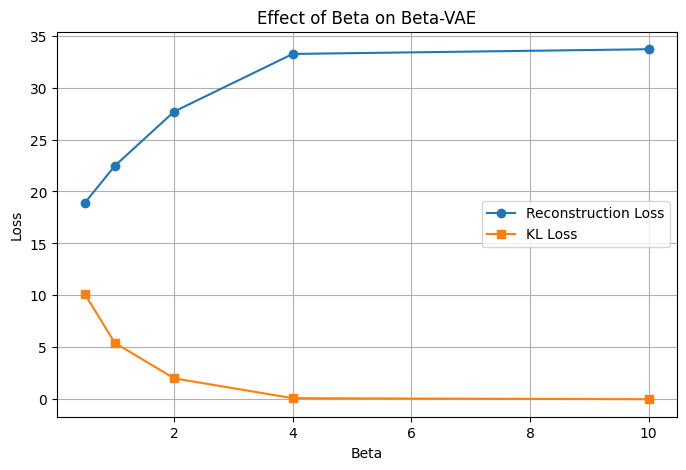

In [16]:
plt.figure(figsize=(8,5))

plt.plot(
    beta_values,
    recon_losses,
    marker='o',
    label='Reconstruction Loss'
)

plt.plot(
    beta_values,
    kl_losses,
    marker='s',
    label='KL Loss'
)

plt.xlabel('Beta')

plt.ylabel('Loss')

plt.title("Effect of Beta on Beta-VAE")

plt.legend()

plt.grid()

plt.show()

Reconstruct Same Digit

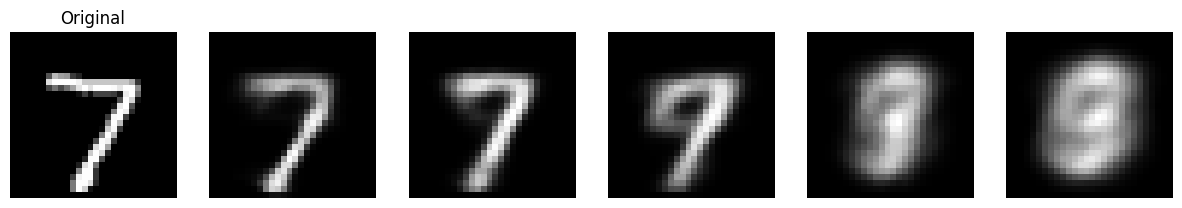

In [19]:
same = x_test[0:1]

fig, axes = plt.subplots(
    1,
    len(beta_values)+1,
    figsize=(15,4)
)

axes[0].imshow(
    same.reshape(28,28),
    cmap='gray'
)

axes[0].set_title(
    "Original"
)

axes[0].axis('off')

for i, beta in enumerate(beta_values):
  model = trained_models[
      beta
  ]

  z_mean, z_log_var, z= \
    model.encoder.predict(
        same,
        verbose=0
    )

  reconstructed = \
    model.decoder.predict(
        z,
        verbose=0
    )

  axes[i+1].imshow(
      reconstructed.reshape(
          28,
          28
      ),
      cmap='gray'
  )

  axes[i+1].axis('off')

plt.show()